# BigGAN + MidJourney: Cat 4 Classes, FFT Mean + CLIP + XGBoost / MLP

Notebook ini melanjutkan eksperimen `08` dengan menambahkan fitur **CLIP image embedding** ke fitur **FFT mean**.

Setup tetap sama:
1. generator: `BigGAN` + `MidJourney`
2. kelas: **4 class kucing yang sama**
3. task: biner `AI vs nature`
4. model: `XGBoost` dan `MLP`

Tujuan notebook ini adalah melihat apakah penambahan sinyal semantik dari CLIP membantu atau tidak ketika dua generator digabung pada kelas konten yang sama.



In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import CLIPModel, CLIPProcessor
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
MULTICLASS_ROOT = PROJECT_ROOT / "data" / "raw" / "genimage_multiclass_balanced"
DATA_ROOT = MULTICLASS_ROOT / "genimage"
DATA_ROOTS = {
    "BigGAN": DATA_ROOT / "BigGAN" / "train",
    "MidJourney": DATA_ROOT / "MidJourney" / "train",
}
MANIFEST_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_manifest.csv"
CLASS_TABLE_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_classes.csv"
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_multiclass_train.csv"
FFT_OUT = PROJECT_ROOT / "artifacts" / "features_fft_mean_biggan_midjourney_multiclass_train.csv"
CLIP_OUT = PROJECT_ROOT / "artifacts" / "features_clip_biggan_midjourney_multiclass_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_multiclass_fft_clip.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_multiclass_fft_clip.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_multiclass_fft_clip.csv"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_OUT_DIM = 64

print("Data root:", DATA_ROOT.resolve())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("CLIP model:", CLIP_MODEL_NAME)


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage
Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
CLIP model: openai/clip-vit-base-patch32


## 1. Audit data per generator

In [2]:
manifest_source = pd.read_csv(MANIFEST_SOURCE)
class_table = pd.read_csv(CLASS_TABLE_SOURCE)

manifest_source["path_exists"] = manifest_source["path"].map(lambda p: Path(p).is_file())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("Class table:", CLASS_TABLE_SOURCE.resolve())
print("Manifest shape:", manifest_source.shape)
print("Jumlah kelas:", manifest_source["imagenet_id"].nunique())
print("Semua path ada:", bool(manifest_source["path_exists"].all()))

display(class_table.head(10))
display(
    manifest_source
    .groupby(["generator", "class_name"])
    .size()
    .rename("count")
    .reset_index()
)
display(
    manifest_source
    .groupby(["generator", "class_name", "imagenet_id", "wordnet_id", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .describe(include="all")
)


Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
Class table: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_classes.csv
Manifest shape: (8000, 16)
Jumlah kelas: 40
Semua path ada: True


,class_id,class_id_str,wnid,label
0,0,0,n01440764,tench
1,1,1,n01443537,goldfish
2,2,2,n01484850,great_white_shark
3,3,3,n01491361,tiger_shark
4,4,4,n01494475,hammerhead
5,5,5,n01496331,electric_ray
6,6,6,n01498041,stingray
7,7,7,n01514668,cock
8,8,8,n01514859,hen
9,9,9,n01518878,ostrich


,generator,class_name,count
0,BigGAN,ai,2000
1,BigGAN,nature,2000
2,MidJourney,ai,2000
3,MidJourney,nature,2000


,generator,class_name,imagenet_id,wordnet_id,content_label,count
count,160,160,160.000000,160,160,160.0
unique,2,2,NaN,40,40,NaN
top,BigGAN,ai,NaN,n01440764,tench,NaN
freq,80,80,NaN,4,4,NaN
mean,NaN,NaN,112.925000,NaN,NaN,50.0
std,NaN,NaN,131.508019,NaN,NaN,0.0
min,NaN,NaN,0.000000,NaN,NaN,50.0
25%,NaN,NaN,9.750000,NaN,NaN,50.0
50%,NaN,NaN,59.500000,NaN,NaN,50.0
75%,NaN,NaN,207.250000,NaN,NaN,50.0


## 2. Bangun manifest gabungan untuk 4 class kucing yang sama


In [3]:
manifest = pd.read_csv(MANIFEST_SOURCE).copy()
manifest["subset_name"] = "biggan_midjourney_multiclass_train"
manifest["split"] = "train"
manifest["path"] = manifest["path"].map(lambda p: str(Path(p).resolve()))

missing_paths = manifest.loc[~manifest["path"].map(lambda p: Path(p).is_file()), "path"].head()
if len(missing_paths):
    raise FileNotFoundError(
        "Ada path manifest yang tidak ditemukan, contoh: "
        + str(missing_paths.tolist())
    )

manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())
display(
    manifest
    .groupby(["generator", "class_name", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .head(20)
)


Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_multiclass_train.csv
Manifest shape: (8000, 15)


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,content_label,imagenet_id,wordnet_id,is_real,y_ai
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1


,generator,y_ai,count
0,BigGAN,0,2000
1,BigGAN,1,2000
2,MidJourney,0,2000
3,MidJourney,1,2000


,generator,class_name,content_label,count
0,BigGAN,ai,Chesapeake_Bay_retriever,50
1,BigGAN,ai,Chihuahua,50
2,BigGAN,ai,Egyptian_cat,50
3,BigGAN,ai,German_short-haired_pointer,50
4,BigGAN,ai,Labrador_retriever,50
5,BigGAN,ai,Persian_cat,50
6,BigGAN,ai,Siamese_cat,50
7,BigGAN,ai,ambulance,50
8,BigGAN,ai,beach_wagon,50
9,BigGAN,ai,black_swan,50


## 3. Ekstraksi FFT mean

In [4]:
if FFT_OUT.exists():
    fft_df = pd.read_csv(FFT_OUT)
    print("Loaded FFT features:", FFT_OUT.resolve())
else:
    def load_gray(path):
        return np.asarray(Image.open(path).convert("L"), dtype=np.float32)

    def extract_fft_mean(gray):
        f = np.fft.fft2(gray)
        mag = np.abs(f)
        phase = np.angle(f)
        return {
            "fft_mag_mean": float(np.mean(mag)),
            "fft_phase_mean": float(np.mean(phase)),
            "fft_phase_cos_mean": float(np.mean(np.cos(phase))),
            "fft_phase_sin_mean": float(np.mean(np.sin(phase))),
        }

    fft_rows = []
    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        gray = load_gray(row.path)
        feats = extract_fft_mean(gray)
        fft_rows.append({"image_id": row.image_id, **feats})
        if idx % 200 == 0:
            print(f"Processed FFT {idx}/{len(manifest)} images")

    fft_df = pd.DataFrame(fft_rows)
    fft_df.to_csv(FFT_OUT, index=False)
    print("Saved FFT features:", FFT_OUT.resolve())

print("FFT shape:", fft_df.shape)
display(fft_df.head())


Loaded FFT features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_fft_mean_biggan_midjourney_multiclass_train.csv
FFT shape: (8000, 5)


,image_id,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
0,BigGAN_ai_000_000000,2211.584961,0.000192,0.014415,0.000000e+00
1,BigGAN_ai_000_000001,1451.847412,0.000575,0.016275,-1.396984e-09
2,BigGAN_ai_000_000002,1764.804443,0.000192,-0.009851,-9.313226e-10
3,BigGAN_ai_000_000003,1413.531738,0.000383,-0.006602,-9.313226e-10
4,BigGAN_ai_000_000004,2255.782471,0.000383,0.018405,-5.238689e-10


## 4. Ekstraksi CLIP image embedding
Notebook ini memakai model yang sudah kita cache: `openai/clip-vit-base-patch32`. Untuk menjaga ukuran fitur tetap ringan, embedding CLIP dipotong ke 64 dimensi pertama.

In [5]:
if CLIP_OUT.exists():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Loaded existing CLIP features later; skip CLIP model initialization.")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
    model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, local_files_only=True).to(device)
    model.eval()
    print("device:", device)
    print("projection_dim:", model.config.projection_dim)


Loaded existing CLIP features later; skip CLIP model initialization.


In [6]:
if CLIP_OUT.exists():
    clip_df = pd.read_csv(CLIP_OUT)
    print("Loaded CLIP features:", CLIP_OUT.resolve())
else:
    def extract_clip_vector(path: str, out_dim: int = 64):
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model.get_image_features(**inputs)
            if hasattr(out, "pooler_output"):
                feats = out.pooler_output
            elif torch.is_tensor(out):
                feats = out
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(out)}")
            feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
        vec = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
        if out_dim < vec.shape[0]:
            vec = vec[:out_dim]
        elif out_dim > vec.shape[0]:
            vec = np.concatenate([vec, np.zeros(out_dim - vec.shape[0], dtype=np.float32)])
        return vec

    clip_rows = []
    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        vec = extract_clip_vector(row.path, out_dim=CLIP_OUT_DIM)
        item = {"image_id": row.image_id}
        for i, v in enumerate(vec):
            item[f"clip_feat_{i:03d}"] = float(v)
        clip_rows.append(item)
        if idx % 100 == 0:
            print(f"Processed CLIP {idx}/{len(manifest)} images")

    clip_df = pd.DataFrame(clip_rows)
    clip_df.to_csv(CLIP_OUT, index=False)
    print("Saved CLIP features:", CLIP_OUT.resolve())

display(clip_df.head())


Loaded CLIP features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_clip_biggan_midjourney_multiclass_train.csv


,image_id,clip_feat_000,clip_feat_001,clip_feat_002,clip_feat_003,clip_feat_004,clip_feat_005,clip_feat_006,clip_feat_007,clip_feat_008,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,BigGAN_ai_000_000000,0.023383,0.033415,0.000783,0.000693,0.001556,0.028215,-0.023073,0.015947,0.060079,...,0.033839,0.013861,0.008991,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896
1,BigGAN_ai_000_000001,-0.005320,0.025451,-0.001197,0.040806,0.008424,0.023826,-0.031863,-0.036118,0.093952,...,0.003529,-0.015651,0.038348,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008
2,BigGAN_ai_000_000002,0.018574,0.012184,0.006055,0.021351,-0.015919,-0.043677,-0.025114,0.006281,0.049114,...,0.043169,-0.033627,0.021230,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130
3,BigGAN_ai_000_000003,0.024487,0.034794,-0.013841,-0.000896,0.002640,0.002252,-0.023318,0.002641,0.074824,...,0.037015,-0.001909,-0.009840,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082
4,BigGAN_ai_000_000004,-0.003053,0.005584,0.027832,0.041834,0.018493,-0.015387,-0.031849,-0.006884,0.080148,...,0.007375,-0.012183,0.069066,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019


## 5. Gabungkan FFT + CLIP menjadi feature vector

In [7]:
data = manifest.merge(fft_df, on="image_id", how="inner").merge(clip_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = [
    c for c in data.columns
    if c.startswith(("fft_", "clip_feat_")) or c in ["piqe", "brisque", "niqe"]
]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (8000, 83)
Feature dims: 68
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_multiclass_fft_clip.csv


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.033839,0.013861,0.008991,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.003529,-0.015651,0.038348,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.043169,-0.033627,0.021230,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.037015,-0.001909,-0.009840,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.007375,-0.012183,0.069066,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019


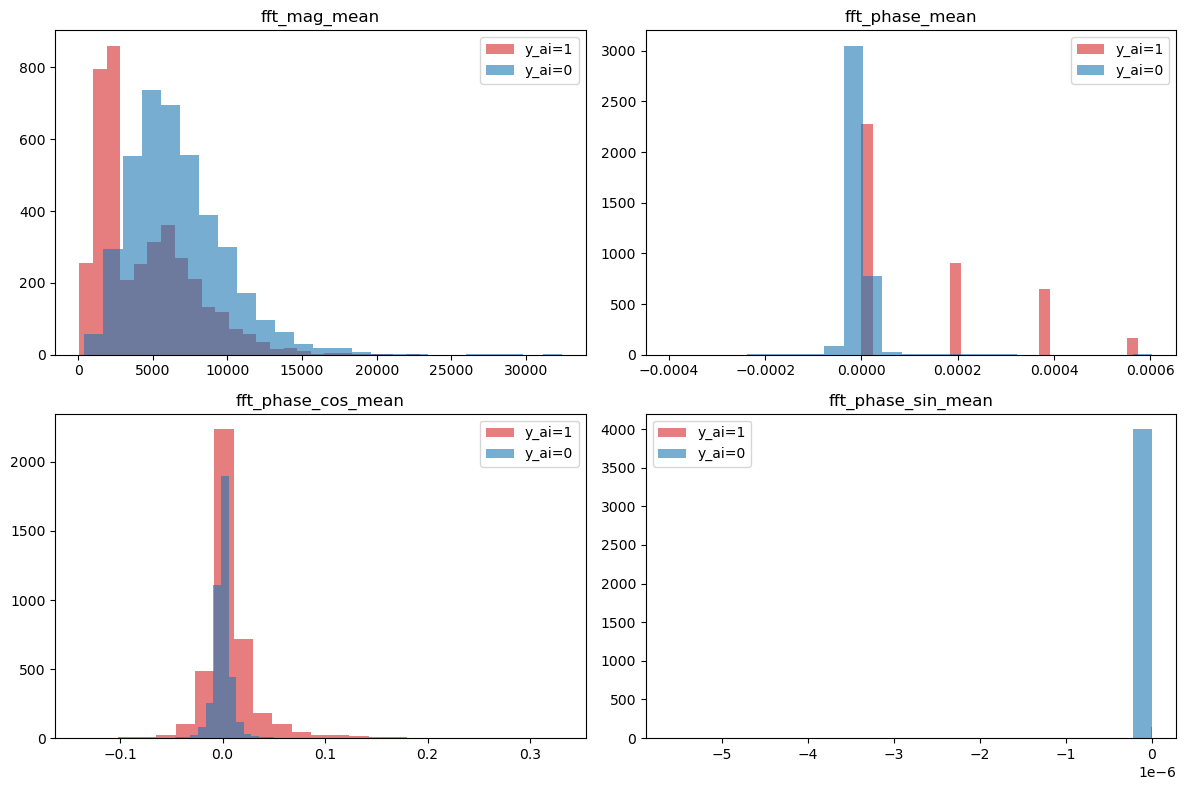

In [8]:
fft_cols = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, fft_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=25, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Split 80:20 dengan stratifikasi gabungan

In [9]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (6400, 68) (6400,)
Eval: (1600, 68) (1600,)


## 7. Train baseline dengan FFT + CLIP

In [10]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,XGBoost,0.981875,0.981795,0.996673
1,MLP,0.956875,0.957169,0.989552


## 8. Confusion matrix model terbaik

Best model: XGBoost

              precision    recall  f1-score   support

      nature       0.98      0.99      0.98       800
          ai       0.99      0.98      0.98       800

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



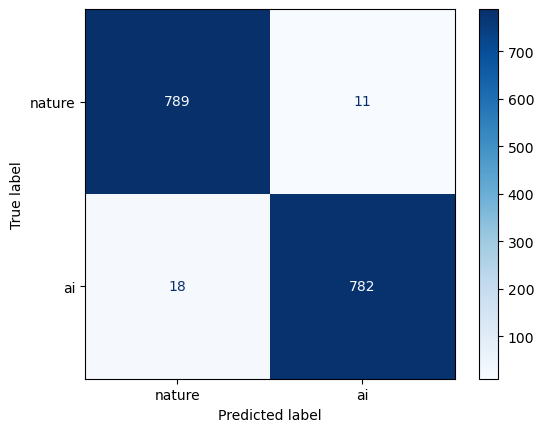

In [11]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 9. Simpan hasil

In [12]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "fft_mean_plus_clip"
metrics_df["clip_model"] = CLIP_MODEL_NAME
metrics_df["clip_out_dim"] = CLIP_OUT_DIM
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = "biggan_midjourney_multiclass_train"
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())


Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_multiclass_fft_clip.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_multiclass_fft_clip.csv


,model,accuracy,f1,auroc,feature_set,clip_model,clip_out_dim,split_protocol,subset_name,n_total,n_train,n_eval
0,XGBoost,0.981875,0.981795,0.996673,fft_mean_plus_clip,openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600
1,MLP,0.956875,0.957169,0.989552,fft_mean_plus_clip,openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,BigGAN_nature_436_003899,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02814533,beach_wagon,0,XGBoost,0.017015,0
1,MidJourney_ai_107_006446,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,107,jellyfish,1,XGBoost,0.993280,1
2,BigGAN_ai_014_001413,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,014,indigo_bunting,1,XGBoost,0.998385,1
3,BigGAN_ai_102_002207,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,102,echidna,1,XGBoost,0.995255,1
4,BigGAN_nature_016_001690,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n01560419,bulbul,0,XGBoost,0.003052,0


## 10. Catatan interpretasi
Notebook ini adalah langkah pertama untuk melihat kontribusi CLIP pada setup dua generator dan empat class yang sama. Cara membacanya sederhana: bandingkan hasil notebook ini dengan notebook `08`. Jika naik, CLIP membantu. Jika tidak naik atau turun, berarti `FFT mean` saja sudah sangat kuat untuk setup ini.